In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator

import pandas as pd

files = {
    'Native': '../../outputs/krylov/native/summary_krylov.csv',
    'SME': '../../outputs/krylov/sme/summary_krylov.csv', 
    'SME+SEV': '../../outputs/krylov/sev/summary_krylov.csv'
}

dfs = []

for mode, path in files.items():
    temp_df = pd.read_csv(path)
    temp_df.insert(0, 'Mode', mode)
    dfs.append(temp_df)

df_raw = pd.concat(dfs, ignore_index=True)
group_cols = ['Mode', 'Algo', 'Matrix', 'Cores', 'NUMA', 'Arg1', 'Arg2', 'Arg3']

def get_median_time_run(group):
    total_time = group['SpMVTime'] + group['MgmtTime']
    median_time = total_time.median()
    idx_nearest = (total_time - median_time).abs().idxmin()
    return group.loc[idx_nearest]

df_median_run = (
    df_raw.groupby(group_cols, group_keys=False)
      .apply(get_median_time_run, include_groups=False)
      .reset_index()
)

df_median_run['total_time'] = df_median_run['SpMVTime'] + df_median_run['MgmtTime']
df_median_run['ns_per_op'] = ((df_median_run['total_time']) * 1e9) / df_median_run['N_Ops']

df = df_median_run.copy()

In [104]:
df

,Mode,Algo,Matrix,Cores,NUMA,Arg1,Arg2,Arg3,Run,SpMVTime,MgmtTime,N_Ops,Insn,Cycl,RefCycl,Cache_Miss,Stalls,PgFault,total_time,ns_per_op
0,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,8,2,10,4.0,4.04843,2.970230,75.0,6.661991e+10,2.554016e+10,1.656659e+10,3.564060e+07,1.472023e+08,10922.0,7.018660,9.358213e+07
1,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,11,2,10,8.0,4.29780,3.963210,99.0,1.021891e+11,8.235633e+10,5.342032e+10,4.652995e+07,6.295593e+08,6922.0,8.261010,8.344455e+07
2,Native,arnoldi,symmetric/Bump2911.bin,8,localalloc,11,2,10,6.0,4.33104,3.958010,99.0,1.032123e+11,1.527238e+11,9.906408e+10,5.022962e+07,1.356632e+09,7958.0,8.289050,8.372778e+07
3,Native,arnoldi,symmetric/Bump2911.bin,16,localalloc,22,2,10,1.0,4.17306,7.547570,187.0,1.982309e+11,3.166637e+11,2.061218e+11,1.021165e+08,2.573390e+09,9126.0,11.720630,6.267717e+07
4,Native,arnoldi,symmetric/Bump2911.bin,24,localalloc,26,2,10,4.0,4.08289,8.831990,219.0,2.361519e+11,4.709404e+11,3.057589e+11,1.263311e+08,3.739195e+09,10453.0,12.914880,5.897205e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,SME+SEV,lanczos,symmetric/nd6k.bin,24,localalloc,819,2,10,1.0,4.30465,0.746971,7237.0,3.613631e+11,4.402054e+11,3.377855e+15,3.377700e+15,6.844942e+10,1076.0,5.051621,6.980269e+05
806,SME+SEV,lanczos,symmetric/nd6k.bin,32,interleave,1105,2,10,17.0,4.26174,1.114710,9811.0,4.937777e+11,6.237477e+11,4.045932e+11,5.253294e+08,1.283722e+11,1101.0,5.376450,5.480022e+05
807,SME+SEV,lanczos,symmetric/nd6k.bin,32,localalloc,1105,2,10,5.0,5.47985,1.125280,9811.0,4.940940e+11,7.664147e+11,4.971339e+11,5.341900e+08,1.327942e+11,1102.0,6.605130,6.732372e+05
808,SME+SEV,lanczos,symmetric/nd6k.bin,48,interleave,1425,2,10,17.0,5.22318,1.797850,12691.0,6.538479e+11,1.222814e+12,7.931830e+11,8.293419e+08,3.101877e+11,1153.0,7.021030,5.532291e+05


In [105]:
#Massive Perf overflow problem
df_sorted = df_raw.sort_values(by=group_cols)
df_sorted.head(50)

,Mode,Algo,Matrix,Cores,NUMA,Run,Arg1,Arg2,Arg3,SpMVTime,MgmtTime,N_Ops,Insn,Cycl,RefCycl,Cache_Miss,Stalls,PgFault
189,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,1,8,2,10,4.05554,2.97276,75,281509791992902,281488563221994,16587521232,35443068,146397615,10436
459,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,2,8,2,10,4.04140,2.97196,75,281478887053130,281476722956934,16549269240,35647372,146495342,10922
729,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,3,8,2,10,4.04864,2.97953,75,66619913765,25566262453,140742076921949,140737497682627,146806519,10918
999,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,4,8,2,10,4.04843,2.97023,75,66619913765,25540162854,16566592104,35640603,147202339,10922
1269,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,5,8,2,10,4.03842,2.97218,75,66619913854,25514667611,16550057400,35678757,146489417,10921
190,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,1,11,2,10,4.18843,3.87373,99,102185404686,80411835450,52159031016,46849746,619520392,7944
460,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,2,11,2,10,4.29729,3.96451,99,102188740275,82343667766,53412111024,47081769,627165185,7945
730,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,3,11,2,10,4.18969,3.87626,99,703708005091236,703703618909553,140789634076231,140737535246235,619199200,7943
1000,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,4,11,2,10,4.32915,3.99895,99,102188897920,82880964157,703709857600804,703687460988169,633260294,7433
1270,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,5,11,2,10,4.40881,4.05602,99,102191712292,84314238261,54690314472,47296775,640668476,7947


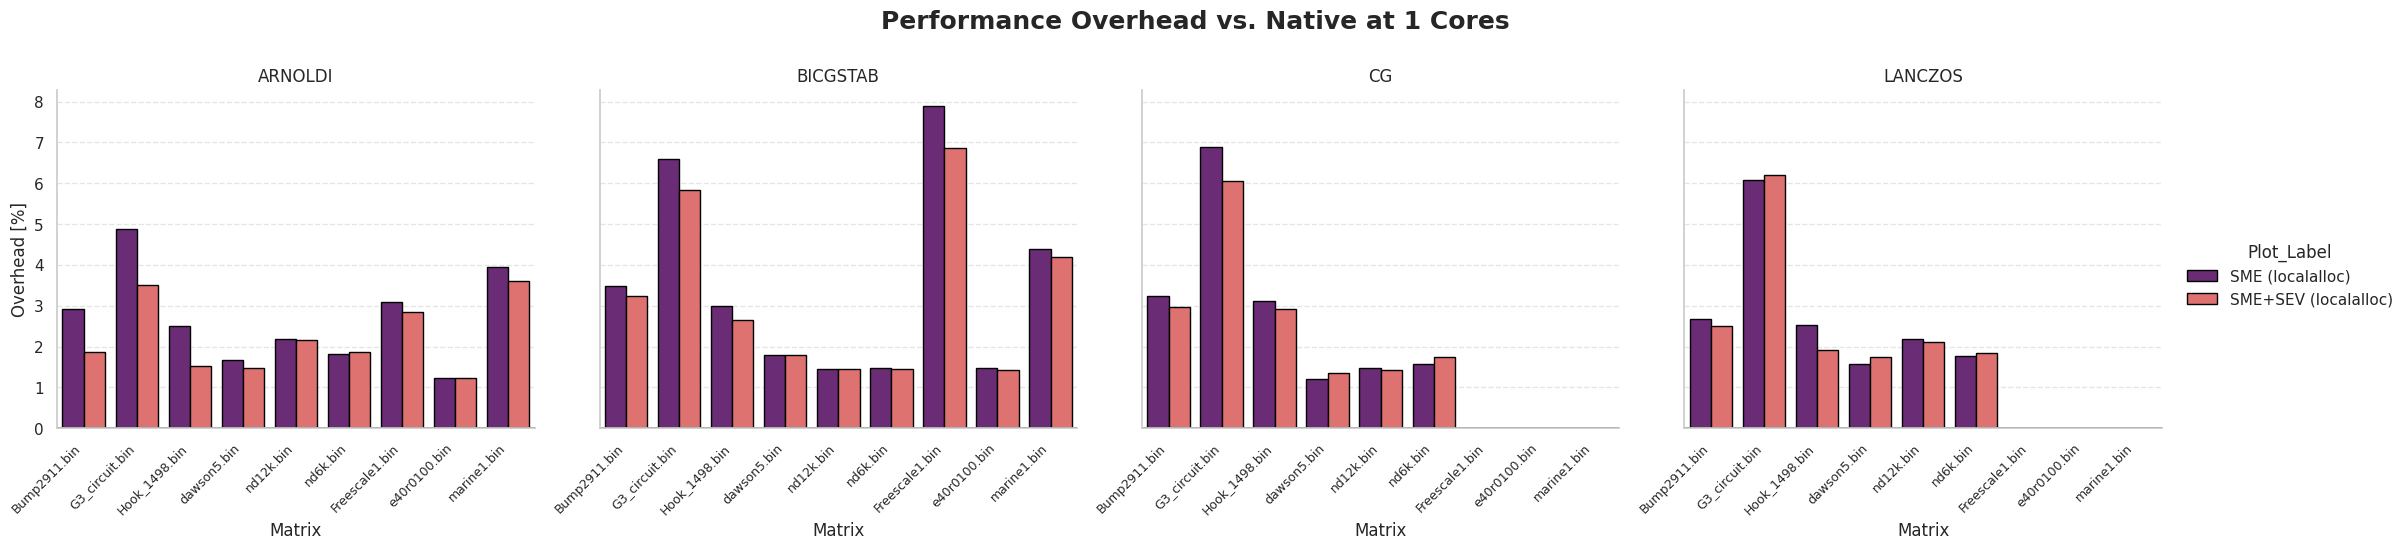

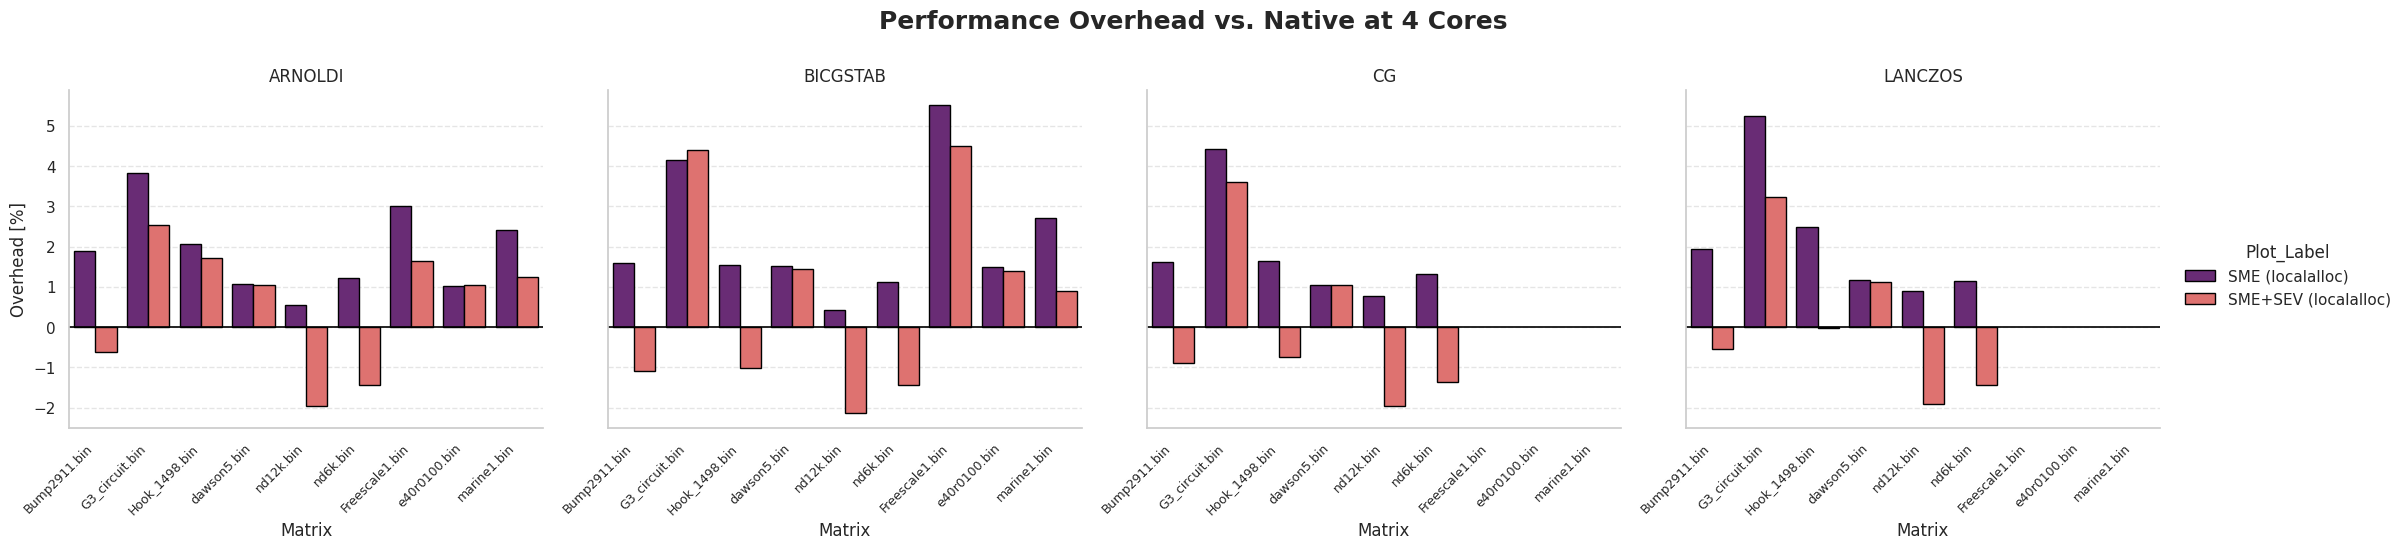

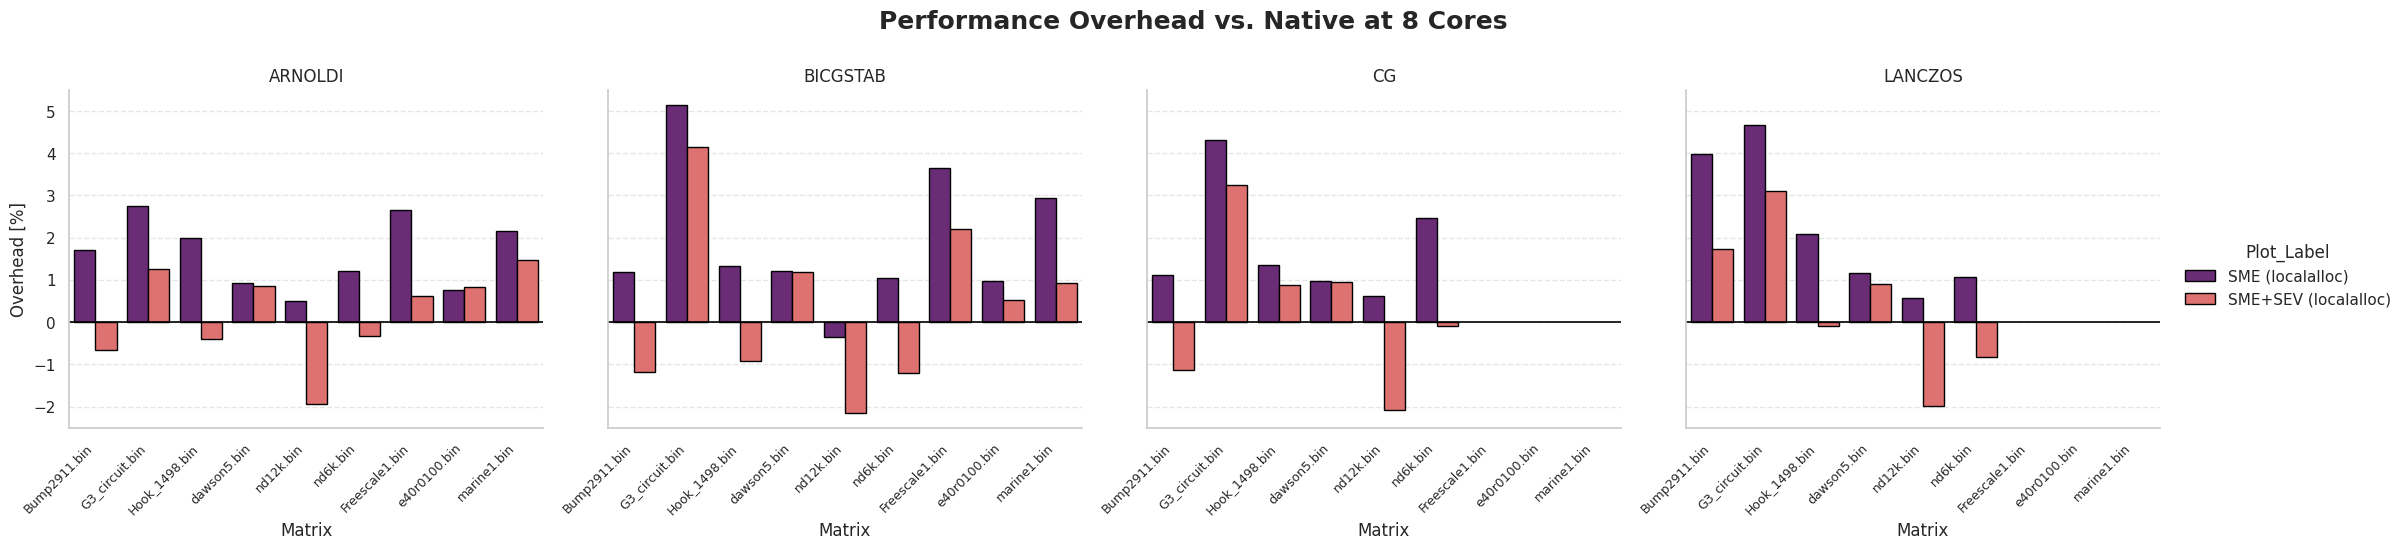

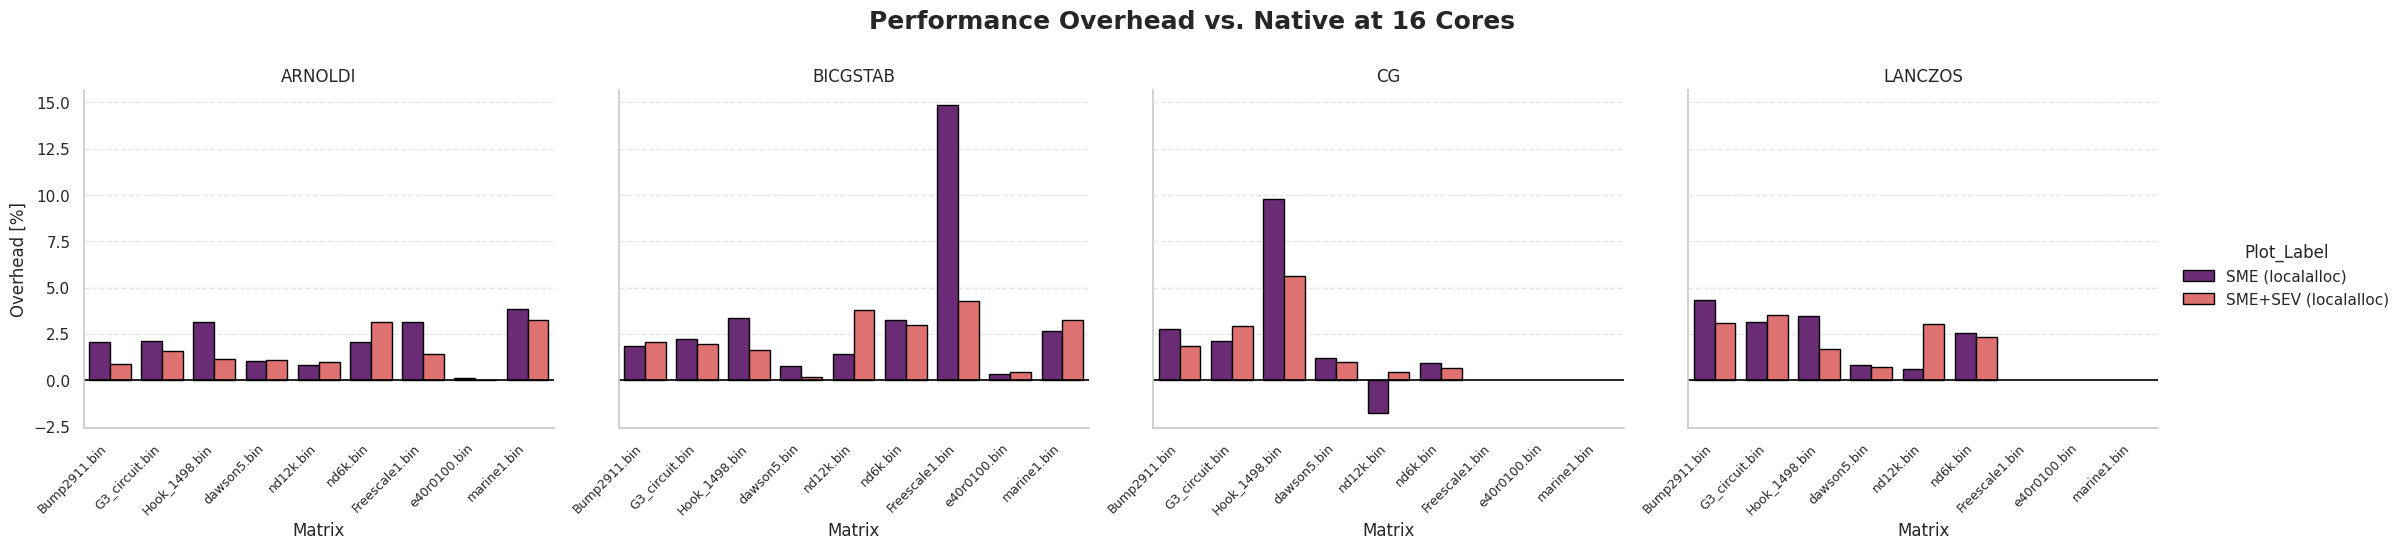

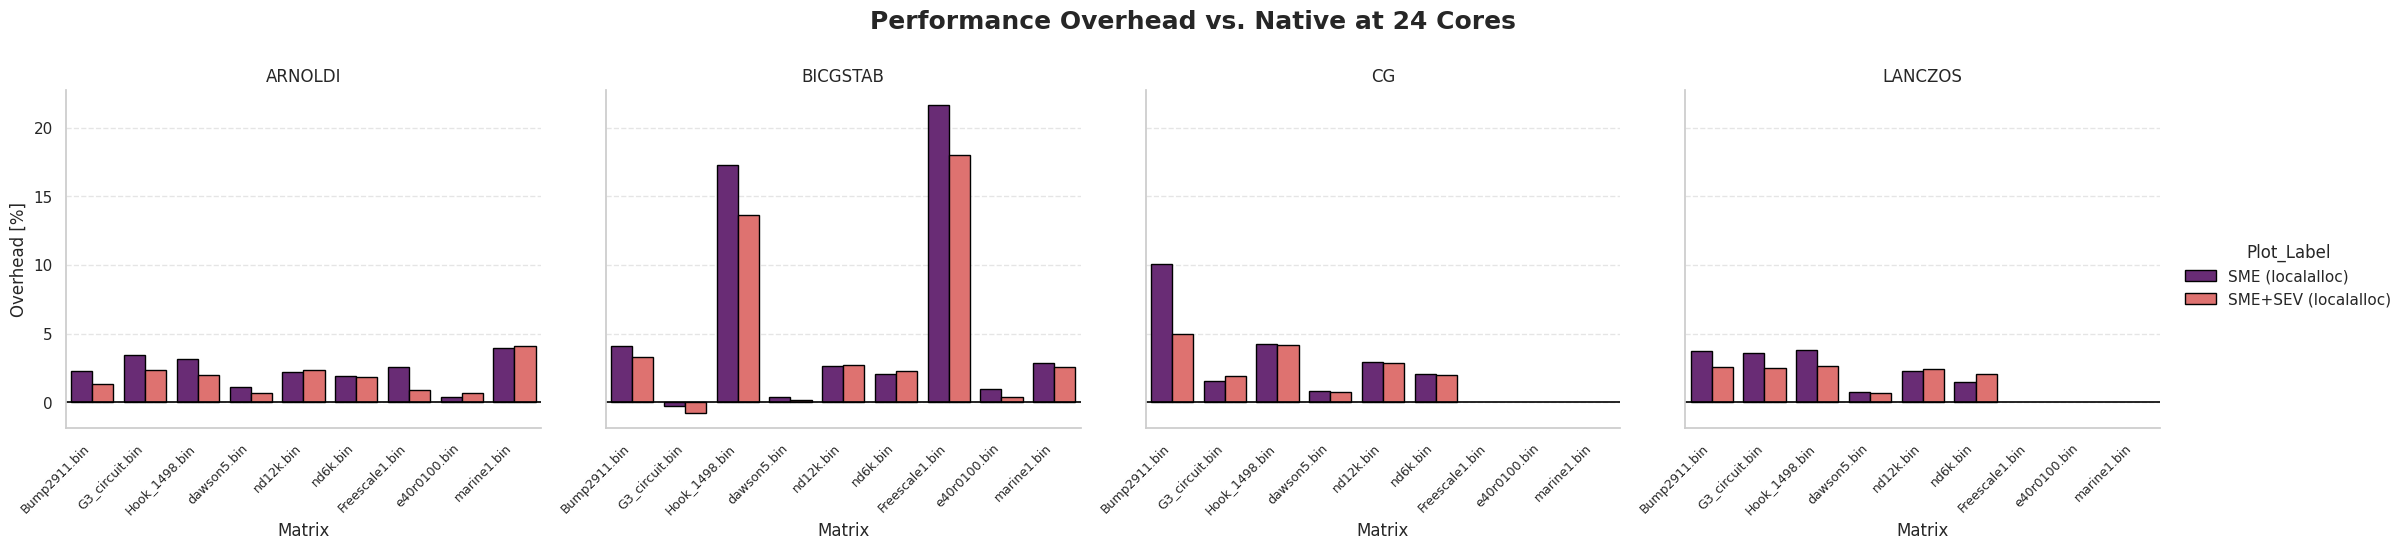

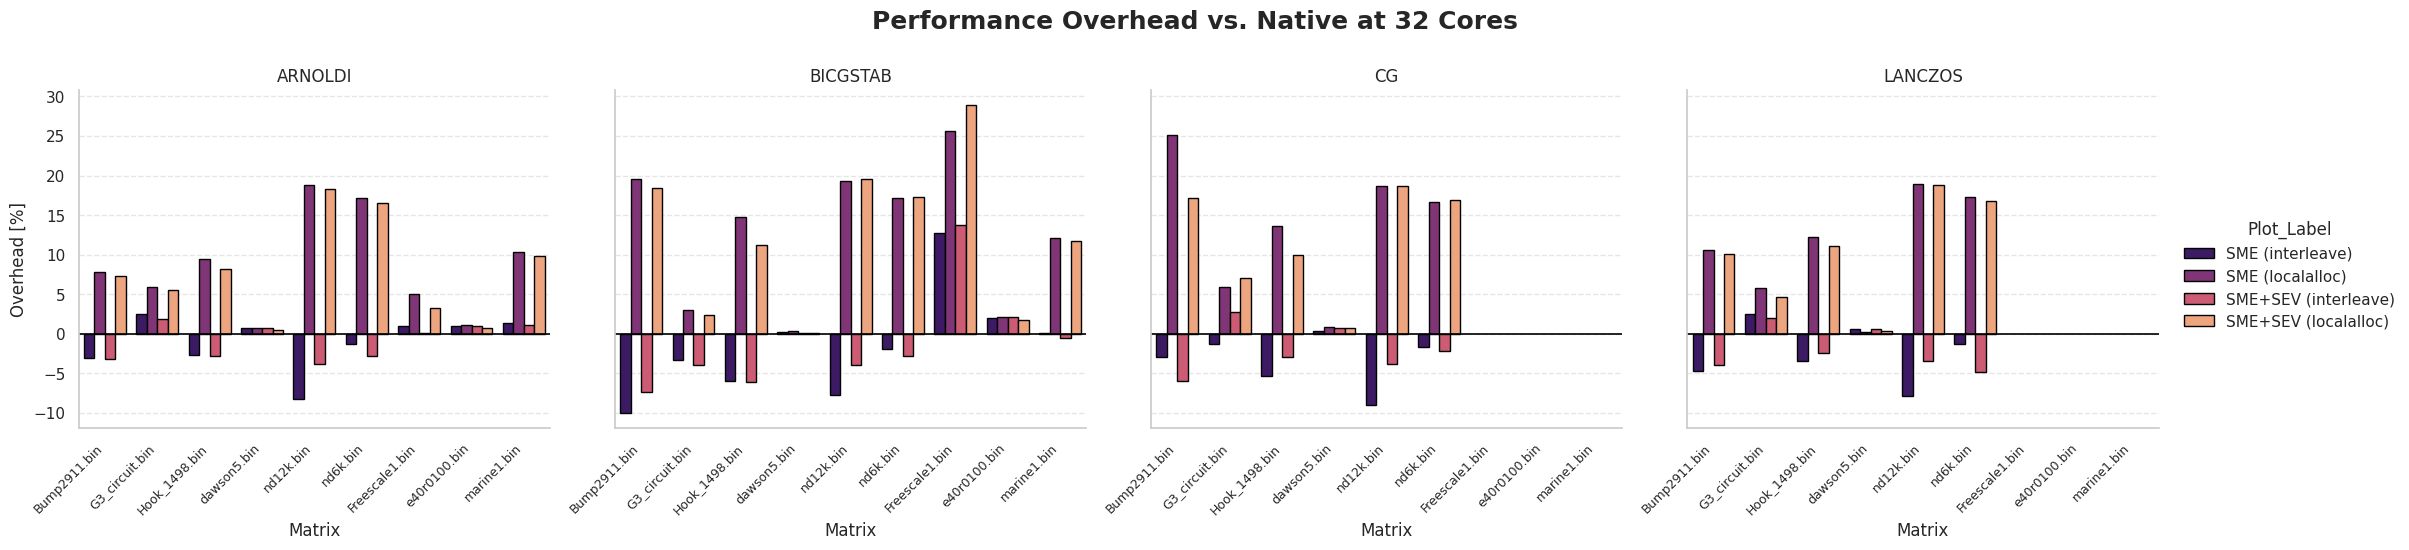

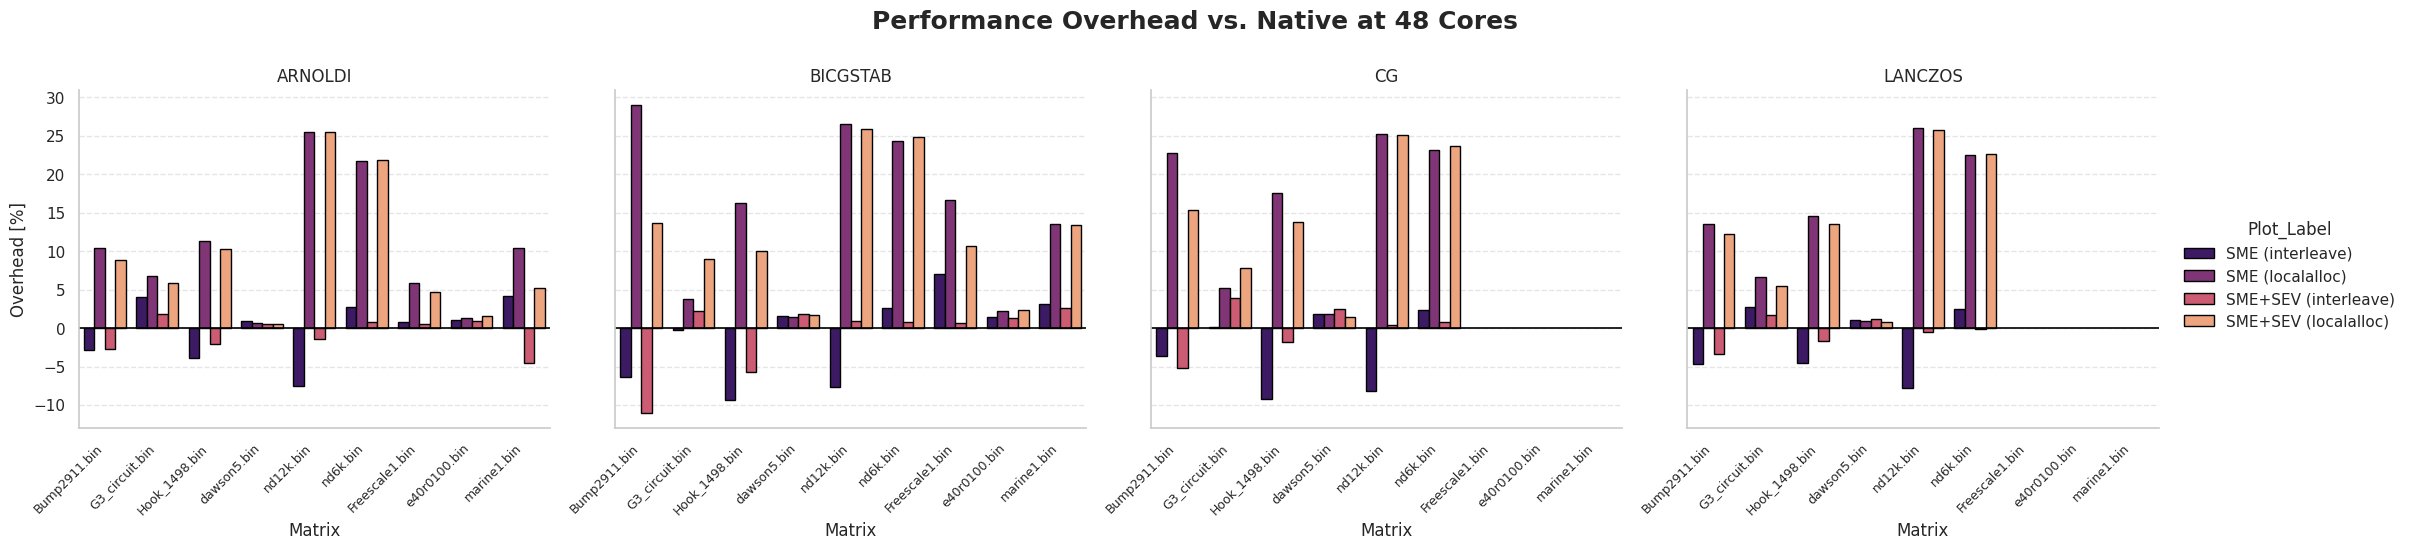

In [106]:
native_df = df[df['Mode'] == 'Native'].copy()
match_cols = ['Algo', 'Matrix', 'Cores', 'Arg1', 'Arg2', 'Arg3']

native_base = (
    native_df.groupby(match_cols)['ns_per_op']
    .median()
    .reset_index()
    .rename(columns={'ns_per_op': 'native_ref'})
)

df_diff = df.merge(native_base, on=match_cols)
df_diff['pct_diff'] = (df_diff['ns_per_op'] / df_diff['native_ref'] - 1) * 100
df_diff['Plot_Label'] = df_diff['Mode'] + " (" + df_diff['NUMA'] + ")"

plot_df = df_diff[df_diff['Mode'] != 'Native'].copy()
plot_df['Matrix_Label'] = plot_df['Matrix'].str.split('/').str[-1]
plot_df['Algo'] = plot_df['Algo'].str.upper()

unique_cores = sorted(plot_df['Cores'].unique())

for core in unique_cores:
    core_data = plot_df[plot_df['Cores'] == core]

    g = sns.catplot(
        data=core_data,
        x='Matrix_Label',
        y='pct_diff',
        hue='Plot_Label',
        col='Algo',
        kind='bar',
        palette='magma',
        edgecolor='black',
        height=5,
        aspect=1.1,
        sharey=True
    )

    g.set_titles("{col_name}")
    g.set_axis_labels("Matrix", "Overhead [%]")
    g.set_xticklabels(rotation=45, ha='right', fontsize=9)

    for ax in g.axes.flat:
        ax.axhline(0, color='black', linewidth=1.2)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    g.figure.subplots_adjust(top=0.82)
    g.figure.suptitle(
        f'Performance Overhead vs. Native at {core} Cores',
        fontsize=18,
        fontweight='bold'
    )

    plt.show()
